Proyecto INF497
--Integrantes: José Manzano y Manuel Silva

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import osmnx as ox
from shapely.geometry import Point

# Configuración visual
sns.set_theme(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.5 MB/s eta 0:00:00


Celda 2: Recreación del Análisis Visual Exploratorio (Macro)
Basándonos en tus datos, donde la Región de Valparaíso presenta una crisis más aguda con 335 campamentos en comparación con los 153 de la RM , y concentra 30.458 familias frente a las 22.223 de la capital, podemos generar los gráficos así:

/tmp/ipykernel_772/3751448023.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=df_macro, x='Región', y='Cantidad de Campamentos', palette=['#428bca', '#d9534f'], edgecolor='black')
/tmp/ipykernel_772/3751448023.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=df_macro, x='Región', y='Cantidad de Familias', palette=['#428bca', '#d9534f'], edgecolor='black')


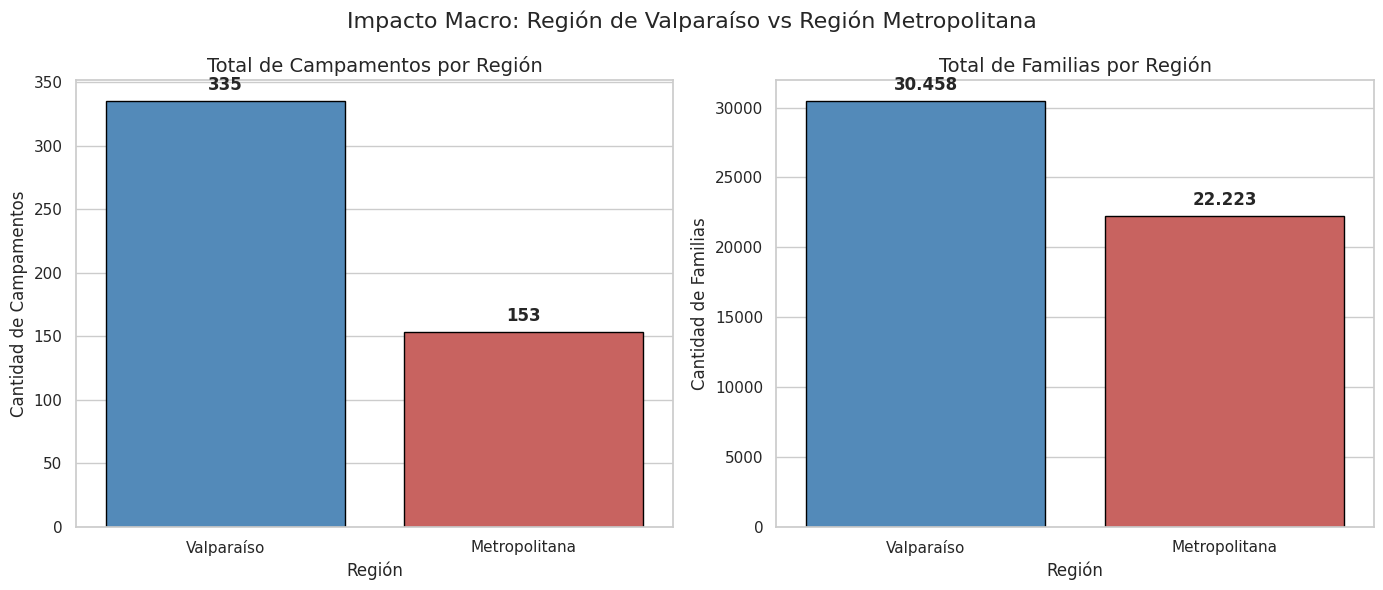

In [ ]:
# DataFrame datos macro
datos_macro = {
    'Región': ['Valparaíso', 'Metropolitana'],
    'Cantidad de Campamentos': [335, 153],
    'Cantidad de Familias': [30458, 22223]
}
df_macro = pd.DataFrame(datos_macro)

# Configurar figura
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Impacto Macro: Región de Valparaíso vs Región Metropolitana', fontsize=16)

# Gráfico campamentos
sns.barplot(ax=axes[0], data=df_macro, x='Región', y='Cantidad de Campamentos', palette=['#428bca', '#d9534f'], edgecolor='black')
axes[0].set_title('Total de Campamentos por Región', fontsize=14)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# Gráfico familias
sns.barplot(ax=axes[1], data=df_macro, x='Región', y='Cantidad de Familias', palette=['#428bca', '#d9534f'], edgecolor='black')
axes[1].set_title('Total de Familias por Región', fontsize=14)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}'.replace(',', '.'), (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

In [ ]:
import xml.etree.ElementTree as ET
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon

def cargar_kml_puro_python(ruta_archivo):
    # Parsear XML
    tree = ET.parse(ruta_archivo)
    root = tree.getroot()

    # Detectar namespace
    namespace = ""
    if root.tag.startswith("{"):
        namespace = root.tag.split("}")[0] + "}"

    elementos = []

    # Buscar Placemarks
    for placemark in root.findall(f".//{namespace}Placemark"):
        nombre_nodo = placemark.find(f"{namespace}name")
        desc_nodo = placemark.find(f"{namespace}description")

        nombre = nombre_nodo.text if nombre_nodo is not None else "Sin Nombre"
        descripcion = desc_nodo.text if desc_nodo is not None else ""

        # Extraer puntos
        punto_nodo = placemark.find(f".//{namespace}Point/{namespace}coordinates")
        if punto_nodo is not None and punto_nodo.text:
            coordenadas_txt = punto_nodo.text.strip()
            partes = coordenadas_txt.split(',')
            if len(partes) >= 2:
                lon = float(partes[0])
                lat = float(partes[1])
                elementos.append({
                    'Name': nombre,
                    'Description': descripcion,
                    'geometry': Point(lon, lat)
                })
            continue 

        # Extraer polígonos
        poligono_nodo = placemark.find(f".//{namespace}Polygon//{namespace}coordinates")
        if poligono_nodo is not None and poligono_nodo.text:
            coordenadas_txt = poligono_nodo.text.strip()
            puntos_poligono = []
            for coord_str in coordenadas_txt.split():
                partes = coord_str.split(',')
                if len(partes) >= 2:
                    puntos_poligono.append((float(partes[0]), float(partes[1])))
            if len(puntos_poligono) >= 3:
                elementos.append({
                    'Name': nombre,
                    'Description': descripcion,
                    'geometry': Polygon(puntos_poligono)
                })

    # Crear GeoDataFrame
    gdf = gpd.GeoDataFrame(elementos, crs="EPSG:4326")
    return gdf

# Cargar datos
ruta_kml = 'Fuentes de Datos/doc.kml'
gdf_campamentos = cargar_kml_puro_python(ruta_kml)

print(f"Cargados {len(gdf_campamentos)} elementos.")
display(gdf_campamentos.head())

¡Éxito! Se cargaron 1428 elementos desde el archivo KML.


,Name,Description,geometry
0,Lomas de Ramón Ángel Jara,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","POLYGON ((-71.40614 -33.07103, -71.40563 -33.0..."
1,Pompeya Sur,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","POLYGON ((-71.47948 -33.06025, -71.47795 -33.0..."
2,Mirador troncal sur,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","POLYGON ((-71.46351 -33.05897, -71.46406 -33.0..."
3,Comunidad Antumapu,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","POLYGON ((-71.40487 -33.07149, -71.40482 -33.0..."
4,Nueva Toltén,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","POLYGON ((-71.36994 -33.068, -71.37026 -33.067..."


In [ ]:
import osmnx as ox

# Definir el lugar de búsqueda
lugar = "Viña del Mar, Región de Valparaíso, Chile"

# Definir las etiquetas de OSM para los servicios esenciales
tags_servicios = {
    'amenity': ['hospital', 'clinic', 'school', 'kindergarten'],
    'public_transport': ['stop_position', 'platform'],
    'highway': ['bus_stop']
}

print("Descargando datos de OpenStreetMap... esto puede tardar un poco.")
# Descargar las geometrías
servicios_osm = ox.features_from_place(lugar, tags=tags_servicios)

# Filtrar solo los puntos
servicios_osm['geometry'] = servicios_osm['geometry'].apply(
    lambda geom: geom.centroid if geom.type == 'Polygon' else geom
)
servicios_puntos = servicios_osm[servicios_osm.geometry.type == 'Point']

print(f"¡Listo! Se extrajeron {len(servicios_puntos)} puntos de servicios en {lugar}.")

Descargando datos de OpenStreetMap... esto puede tardar un poco.
¡Listo! Se extrajeron 661 puntos de servicios en Viña del Mar, Región de Valparaíso, Chile.


/tmp/ipykernel_772/2820310505.py:20: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  lambda geom: geom.centroid if geom.type == 'Polygon' else geom


Los archivos .kml vienen por defecto en coordenadas globales (grados, EPSG:4326). Para medir distancias reales en metros, debemos proyectar ambos mapas al sistema UTM de Chile (Zona 19S, que corresponde al código EPSG:32719).

In [10]:
# 1. Proyectar ambos GeoDataFrames a UTM Zona 19S (EPSG:32719)
gdf_campamentos_utm = gdf_campamentos.to_crs(epsg=32719)
servicios_puntos_utm = servicios_puntos.to_crs(epsg=32719)

# 2. Función para calcular la distancia mínima
def calcular_distancia_minima(punto, gdf_destinos):
    # Calcula la distancia desde un punto a todos los destinos
    distancias = gdf_destinos.geometry.distance(punto)
    # Retorna la distancia mínima encontrada
    return distancias.min()

# 3. Aplicar el cálculo a cada campamento
print("Calculando distancias a servicios...")
gdf_campamentos_utm['Distancia_Minima_Servicios_m'] = gdf_campamentos_utm.geometry.apply(
    lambda geom: calcular_distancia_minima(geom, servicios_puntos_utm)
)

# 4. Mostrar los resultados finales
# Ordenamos de mayor a menor para ver cuáles son los campamentos más aislados
resultados_finales = gdf_campamentos_utm.sort_values(by='Distancia_Minima_Servicios_m', ascending=False)

print("\nTop 5 Campamentos más alejados de servicios esenciales:")
display(resultados_finales[['Name', 'Distancia_Minima_Servicios_m']].head())

Calculando distancias a servicios...

Top 5 Campamentos más alejados de servicios esenciales:


,Name,Distancia_Minima_Servicios_m
1427,Las Lengas,2.230966e+06
1425,Villa Las Etnias,2.228522e+06
1426,Lautaro,2.228365e+06
346,Asociación Villa Nuevo Amanecer,1.618868e+06
340,Villa Fenix,1.618766e+06


In [ ]:
# 1. Filtrar los campamentos usando la columna 'Description'
# Buscamos aquellos donde el texto contenga "Viña del Mar"
gdf_campamentos_vina = gdf_campamentos[
    gdf_campamentos['Description'].str.contains("Viña del Mar", case=False, na=False)
].copy()

print(f"Total de campamentos en Viña del Mar a analizar: {len(gdf_campamentos_vina)}")

# 2. Proyectar a UTM (metros) solo los de Viña del Mar
gdf_campamentos_vina_utm = gdf_campamentos_vina.to_crs(epsg=32719)

# 3. Volver a calcular las distancias, pero ahora con los datos correctos
print("Calculando distancias a servicios para Viña del Mar...")
gdf_campamentos_vina_utm['Distancia_Minima_Servicios_m'] = gdf_campamentos_vina_utm.geometry.apply(
    lambda geom: calcular_distancia_minima(geom, servicios_puntos_utm)
)

# 4. Mostrar los resultados reales
resultados_vina = gdf_campamentos_vina_utm.sort_values(by='Distancia_Minima_Servicios_m', ascending=False)

print("\nTop 5 Campamentos más aislados en Viña del Mar:")
display(resultados_vina[['Name', 'Distancia_Minima_Servicios_m']].head())

Total de campamentos en Viña del Mar a analizar: 114
Calculando distancias a servicios para Viña del Mar...

Top 5 Campamentos más aislados en Viña del Mar:


,Name,Distancia_Minima_Servicios_m
242,Esperanza 2011,1144.969818
218,Villa Vista Hermosa,748.177249
233,Chile despertó,562.173744
237,Villa Bendicion,560.085508
221,Villa Jorge Kaplan,508.764893


Esta celda calcula el comportamiento numérico de la exclusión en los campamentos de Viña del Mar.

In [ ]:
# 1. Estadísticas descriptivas clásicas
print("--- Estadísticas Descriptivas de la Variable de Interés ---")
display(resultados_vina['Distancia_Minima_Servicios_m'].describe())

# 2. Análisis por distribución espacial
Q50 = resultados_vina['Distancia_Minima_Servicios_m'].median()
print(f"\nEl 50% de los campamentos está a más de {Q50:.2f} metros de un servicio esencial.")

--- Estadísticas Descriptivas de la Variable de Interés ---


,Distancia_Minima_Servicios_m
count,114.000000
mean,227.983094
std,170.712316
min,0.000000
25%,111.995921
50%,183.850498
75%,309.357891
max,1144.969818



El 50% de los campamentos está a más de 183.85 metros de un servicio esencial.


Utilizaremos el método de Fisher-Jenks (o Natural Breaks), el cual es metodológicamente ideal para este caso porque agrupa los campamentos reduciendo la varianza interna y maximizando las diferencias entre grupos (identifica brechas reales de aislamiento).

In [ ]:
import geopandas as gpd

# 1. Cargar el shapefile
gdf_comunas = gpd.read_file('Fuentes de Datos/COMUNA_C17.shp')

gdf_comunas_utm = gdf_comunas.to_crs(resultados_vina.crs)

if len(gdf_comunas_utm) == 1:
    gdf_limite_vina_utm = gdf_comunas_utm.copy()
    print("¡Éxito! El archivo contenía un único polígono. Usándolo como fondo de Viña del Mar.")
else:
    # Hacemos un join espacial para ver qué polígono del mapa contiene a nuestros campamentos
    interseccion = gpd.sjoin(gdf_comunas_utm, resultados_vina, predicate='intersects')

    # El índice que más veces se repite representa el contorno de Viña del Mar
    id_vina = interseccion.index.value_counts().idxmax()
    gdf_limite_vina_utm = gdf_comunas_utm.loc[[id_vina]].copy()
    print("¡Éxito! Polígono de Viña del Mar identificado geográficamente mediante intersección.")

¡Éxito! Polígono de Viña del Mar identificado geográficamente mediante intersección.


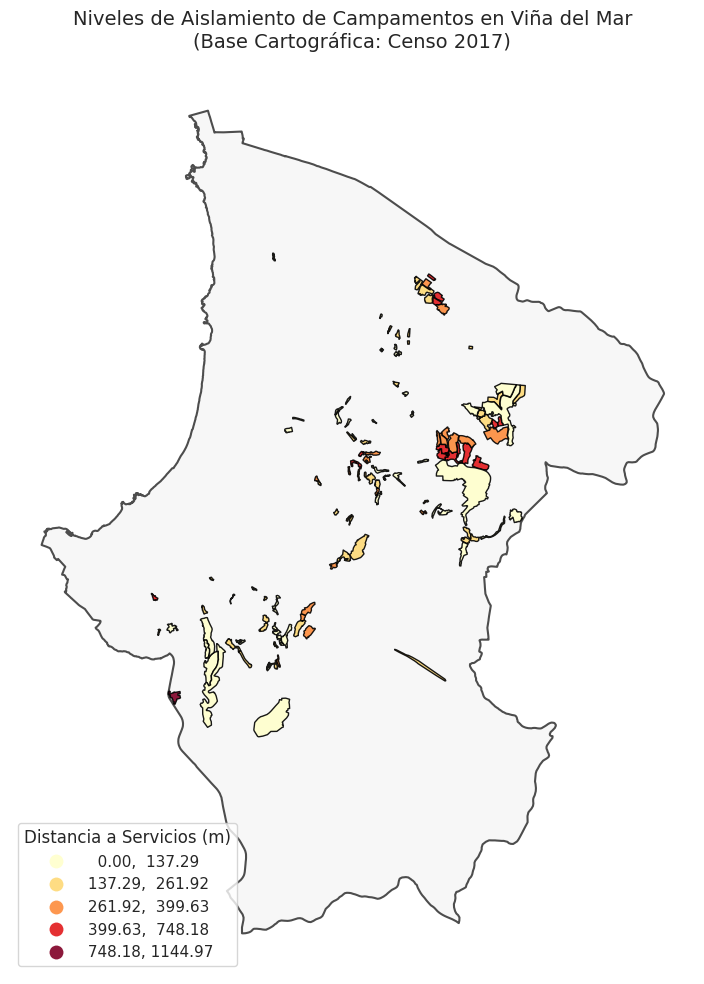

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

gdf_limite_vina_utm.plot(
    ax=ax,
    facecolor='#f7f7f7',
    edgecolor='#4d4d4d',
    linewidth=1.5,
    zorder=1,
    label='Límite Comunal'
)

resultados_vina.plot(
    column='Distancia_Minima_Servicios_m',
    cmap='YlOrRd',
    scheme='FisherJenks',
    k=5,
    legend=True,
    ax=ax,
    legend_kwds={'title': "Distancia a Servicios (m)", 'loc': 'lower left'},
    markersize=45,
    edgecolor='black',
    alpha=0.9,
    zorder=2
)

ax.set_title("Niveles de Aislamiento de Campamentos en Viña del Mar\n(Base Cartográfica: Censo 2017)", fontsize=14, pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('mapa_aislamiento_vina.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

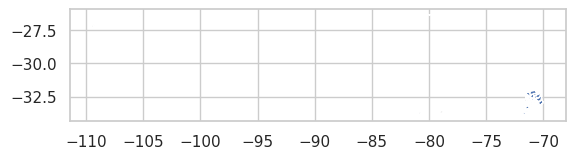

In [15]:
import geopandas as gpd

gdf = gpd.read_file('COMUNA_C17.shp')

gdf.plot()
import matplotlib.pyplot as plt
plt.show()

In [ ]:
gdf_campamentos_utm = gdf_campamentos.to_crs(epsg=32719)
servicios_puntos_utm = servicios_puntos.to_crs(epsg=32719)

# 2. Función para calcular la distancia mínima
def calcular_distancia_minima(punto, gdf_destinos):
    # Calcula la distancia desde un punto a todos los destinos
    distancias = gdf_destinos.geometry.distance(punto)
    # Retorna la distancia mínima encontrada
    return distancias.min()

# 3. Aplicar el cálculo a cada campamento
print("Calculando distancias a servicios...")
gdf_campamentos_utm['Distancia_Minima_Servicios_m'] = gdf_campamentos_utm.geometry.apply(
    lambda geom: calcular_distancia_minima(geom, servicios_puntos_utm)
)

# 4. Mostrar los resultados finales
# Ordenamos de mayor a menor para ver cuáles son los campamentos más aislados
resultados_finales = gdf_campamentos_utm.sort_values(by='Distancia_Minima_Servicios_m', ascending=False)

print("\nTop 5 Campamentos más alejados de servicios esenciales:")
display(resultados_finales[['Name', 'Distancia_Minima_Servicios_m']].head())

Calculando distancias a servicios...

Top 5 Campamentos más alejados de servicios esenciales:


,Name,Distancia_Minima_Servicios_m
1427,Las Lengas,2.230966e+06
1425,Villa Las Etnias,2.228522e+06
1426,Lautaro,2.228365e+06
346,Asociación Villa Nuevo Amanecer,1.618868e+06
340,Villa Fenix,1.618766e+06


--- Análisis de Autocorrelación Espacial Global ---
Índice de Moran (I): 0.2806
Valor p esperado: 0.0010
Z-Score: 5.56
Resultado: Autocorrelación espacial POSITIVA significativa. Los campamentos con niveles de aislamiento similares tienden a agruparse en el espacio.


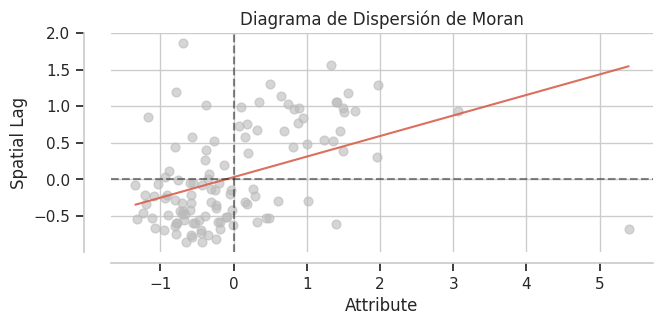

In [17]:
import libpysal
from esda.moran import Moran
from splot.esda import moran_scatterplot

# 1. Definir la estructura espacial (Pesos espaciales por KNN)
w = libpysal.weights.KNN.from_dataframe(resultados_vina, k=5)
w.transform = 'R' # Estandarizar por filas

# 2. Variable bajo análisis
y = resultados_vina['Distancia_Minima_Servicios_m'].values

# 3. Calcular Moran Global
moran = Moran(y, w)

print("--- Análisis de Autocorrelación Espacial Global ---")
print(f"Índice de Moran (I): {moran.I:.4f}")
print(f"Valor p esperado: {moran.p_sim:.4f}")
print(f"Z-Score: {moran.z_sim:.2f}")

# Interpretación automática
if moran.p_sim < 0.05:
    if moran.I > 0:
        print("Resultado: Autocorrelación espacial POSITIVA significativa. Los campamentos con niveles de aislamiento similares tienden a agruparse en el espacio.")
    else:
        print("Resultado: Autocorrelación espacial NEGATIVA significativa (dispersión).")
else:
    print("Resultado: No se rechaza la hipótesis nula. La distribución del aislamiento es espacialmente aleatoria.")

# 4. Graficar el diagrama de dispersión de Moran
fig, ax = moran_scatterplot(moran, aspect_equal=True)
plt.title("Diagrama de Dispersión de Moran")
plt.savefig('mapa_lisa_clusters.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
import numpy as np
from bs4 import BeautifulSoup
import re

# Función para extraer el número de familias desde la tabla HTML del KML
def extraer_familias(html_text):
    if not isinstance(html_text, str): return 1
    soup = BeautifulSoup(html_text, 'html.parser')
    texto = soup.get_text()
    match = re.search(r'(?:Familias|Hogares).*?(\d+)', texto, re.IGNORECASE)
    if match:
        return int(match.group(1))
    return 1 # Valor base si no encuentra dato

# 1. Extraer la variable n_familias
resultados_vina['n_familias'] = resultados_vina['Description'].apply(extraer_familias)

# 2. Corregir el sesgo demográfico
resultados_vina['log_familias'] = np.log1p(resultados_vina['n_familias'])

print("Variable dependiente demográfica extraída y suavizada exitosamente.")
display(resultados_vina[['Name', 'n_familias', 'log_familias']].head())

Variable dependiente demográfica extraída y suavizada exitosamente.


,Name,n_familias,log_familias
242,Esperanza 2011,1,0.693147
218,Villa Vista Hermosa,1,0.693147
233,Chile despertó,1,0.693147
237,Villa Bendicion,1,0.693147
221,Villa Jorge Kaplan,1,0.693147


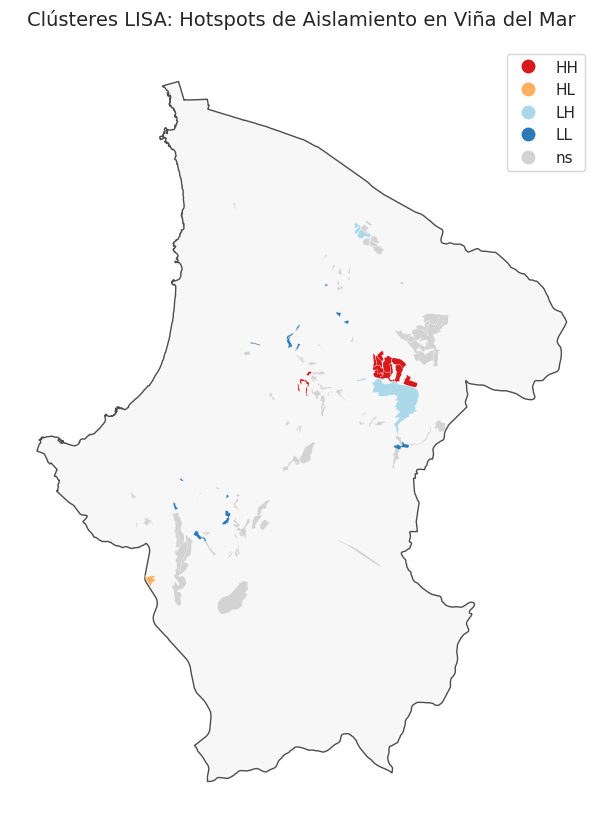

In [ ]:
from esda.moran import Moran_Local
from splot.esda import lisa_cluster
import matplotlib.pyplot as plt

# 1. Calcular el Moran Local para detectar dónde están las trampas de exclusión
moran_loc = Moran_Local(y, w)

# 2. Generar el Mapa de Clústeres (Éste es el que debe ir en el Póster)
fig, ax = plt.subplots(figsize=(10, 10))

gdf_limite_vina_utm.plot(ax=ax, facecolor='#f7f7f7', edgecolor='#4d4d4d', zorder=1)

# Dibujar el clúster espacial
lisa_cluster(moran_loc, resultados_vina, p=0.05, ax=ax, markersize=80, zorder=2)

ax.set_title('Clústeres LISA: Hotspots de Aislamiento en Viña del Mar', fontsize=14, pad=15)
plt.axis('off')

plt.savefig('mapa_lisa_hotspots_real.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
import re

def extraer_familias_kml(html_text):
    if not isinstance(html_text, str): return np.nan

    soup = BeautifulSoup(html_text, 'html.parser')

    # 1. Intentar leerlo como tabla
    for tr in soup.find_all('tr'):
        tds = tr.find_all('td')
        if len(tds) == 2:
            llave = tds[0].get_text(strip=True).upper()
            valor = tds[1].get_text(strip=True)

            # Buscar variaciones de la palabra "familias" en la columna de la izquierda
            if any(palabra in llave for palabra in ['FAMILIA', 'HOGAR', 'N_FAM']):
                try:
                    return int(float(valor))
                except ValueError:
                    pass
    texto = soup.get_text(separator=" ")
    match = re.search(r'(?:FAMILIAS?|HOGARES?|N_FAMILIAS?).*?(\d+)', texto, re.IGNORECASE)
    if match:
        return int(match.group(1))

    return np.nan

# 1. Aplicar el extractor definitivo
resultados_vina['n_familias'] = resultados_vina['Description'].apply(extraer_familias_kml)

# 2. Revisar si hay campamentos que no tenían el dato y rellenarlos con la mediana
n_perdidos = resultados_vina['n_familias'].isna().sum()
if n_perdidos > 0:
    print(f"Atención: {n_perdidos} campamentos no tenían el dato. Se rellenarán con la mediana comunal.")
    mediana = resultados_vina['n_familias'].median()
    resultados_vina['n_familias'] = resultados_vina['n_familias'].fillna(mediana)

# 3. Aplicar logaritmo
resultados_vina['log_familias'] = np.log1p(resultados_vina['n_familias'])

print("\n--- Verificación de Varianza ---")
print(f"Mínimo log_familias: {resultados_vina['log_familias'].min():.2f}")
print(f"Máximo log_familias: {resultados_vina['log_familias'].max():.2f}")
display(resultados_vina[['Name', 'n_familias', 'log_familias']].head(10))


--- Verificación de Varianza ---
Mínimo log_familias: 2.20
Máximo log_familias: 7.57


,Name,n_familias,log_familias
242,Esperanza 2011,153,5.036953
218,Villa Vista Hermosa,160,5.081404
233,Chile despertó,47,3.871201
237,Villa Bendicion,40,3.713572
221,Villa Jorge Kaplan,46,3.850148
231,Colinas de Santa julia,42,3.761200
178,ALTO LAS PALMAS,18,2.944439
184,Los canelos,18,2.944439
223,Los boldos,33,3.526361
157,Allue,21,3.091042


In [ ]:
from pysal.model import spreg

# Variable dependiente (Y): Nivel de aislamiento (Distancia)
y_reg = resultados_vina[['Distancia_Minima_Servicios_m']].values

# Variables predictoras (X): Tamaño demográfico logarítmico
X_reg = resultados_vina[['log_familias']].values
nombres_x = ['log_familias']

# 1. OLS de Diagnóstico (Para elegir entre SAR o SEM)
ols = spreg.OLS(y_reg, X_reg, w=w, name_y='Aislamiento', name_x=nombres_x, spat_diag=True)
print("=== DIAGNÓSTICOS ESPACIALES OLS ===")
print(ols.summary)

# 2. EVALUACIÓN Y EJECUCIÓN DEL MODELO ESPACIAL
print("\n=== MODELO DE ERROR ESPACIAL (SEM) FINAL ===")
modelo_sem = spreg.ML_Error(y_reg, X_reg, w=w, name_y='Aislamiento', name_x=nombres_x)
print(modelo_sem.summary)


=== DIAGNÓSTICOS ESPACIALES OLS ===
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  : Aislamiento                Number of Observations:         114
Mean dependent var  :    227.9831                Number of Variables   :           2
S.D. dependent var  :    170.7123                Degrees of Freedom    :         112
R-squared           :      0.0001
Adjusted R-squared  :     -0.0089
Sum squared residual: 3.29288e+06                F-statistic           :      0.0084
Sigma-square        :   29400.697                Prob(F-statistic)     :      0.9272
S.E. of regression  :     171.466                Log likelihood        :    -747.210
Sigma-square ML     :   28884.895                Akaike info criterion :    1498.420
S.E of regression ML:    169.9556                Schwarz criterion 

/usr/local/lib/python3.12/dist-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


In [ ]:
import pandas as pd
import re
from pysal.model import spreg

# 1. Cargar la nómina del MINVU
df_minvu = pd.read_excel(
    'Fuentes de Datos/Nomina-Campamentos-Catastro-2022.xlsx',
    sheet_name='Nómina Campamentos 2022'   # Nombre exacto de la hoja
)

# 2. Filtrar solo Viña del Mar para no cruzar datos con otras comunas
df_minvu_vina = df_minvu[df_minvu['COMUNA'] == 'Viña del Mar'].copy()

# 3. Limpieza de llaves (Nombres) para asegurar un buen Merge
# Pasamos todo a minúsculas y quitamos espacios en blanco a los lados
resultados_vina['Name_clean'] = resultados_vina['Name'].str.lower().str.strip()
df_minvu_vina['NOMBRE_clean'] = df_minvu_vina['NOMBRE CAMPAMENTO'].str.lower().str.strip()

# 4. Extraer el Año y calcular la Antigüedad
df_minvu_vina['Anio_Creacion'] = df_minvu_vina['AÑO INGRESO CATASTRO'].str.extract(r'(\d{4})').astype(float)

# Calculamos la antigüedad restando el año actual (usaremos 2024 como base del catastro)
df_minvu_vina['antiguedad'] = 2024 - df_minvu_vina['Anio_Creacion']

# 5. Ejecutar el MERGE (Unión espacial-tabular)
resultados_vina = resultados_vina.merge(
    df_minvu_vina[['NOMBRE_clean', 'antiguedad']],
    left_on='Name_clean',
    right_on='NOMBRE_clean',
    how='left'
)

# 6. Rellenar valores nulos
# Como los nombres escritos por TECHO y MINVU pueden tener diferencias menores (ej: "toma" vs "campamento"),
# rellenaremos los campamentos que no cruzaron con la mediana de antigüedad comunal para no perder el polígono.
mediana_antiguedad = resultados_vina['antiguedad'].median()
resultados_vina['antiguedad'] = resultados_vina['antiguedad'].fillna(mediana_antiguedad)

print("Muestra de los datos consolidados:")
display(resultados_vina[['Name', 'log_familias', 'antiguedad']].head())


y_reg = resultados_vina[['Distancia_Minima_Servicios_m']].values

X_reg = resultados_vina[['log_familias', 'antiguedad']].values
nombres_x = ['log_familias', 'antiguedad']

print("\n=== MODELO ESPACIAL DE ERROR (SEM) FINAL ===")
modelo_final = spreg.ML_Error(y_reg, X_reg, w=w, name_y='Aislamiento', name_x=nombres_x)
print(modelo_final.summary)

Muestra de los datos consolidados:


,Name,log_familias,antiguedad
0,Esperanza 2011,5.036953,5.0
1,Villa Vista Hermosa,5.081404,2.0
2,Chile despertó,3.871201,2.0
3,Villa Bendicion,3.713572,5.0
4,Villa Jorge Kaplan,3.850148,5.0



=== MODELO ESPACIAL DE ERROR (SEM) FINAL ===
ML_Error
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  : Aislamiento                Number of Observations:         114
Mean dependent var  :    227.9831                Number of Variables   :           3
S.D. dependent var  :    170.7123                Degrees of Freedom    :         111
Pseudo R-squared    :      0.0620
Log likelihood      :   -733.7708
Sigma-square ML     :  21795.0295                Akaike info criterion :    1473.542
S.E of regression   :    147.6314                Schwarz criterion     :    1481.750

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-------------------------------------

/usr/local/lib/python3.12/dist-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


##
Mas gráficos

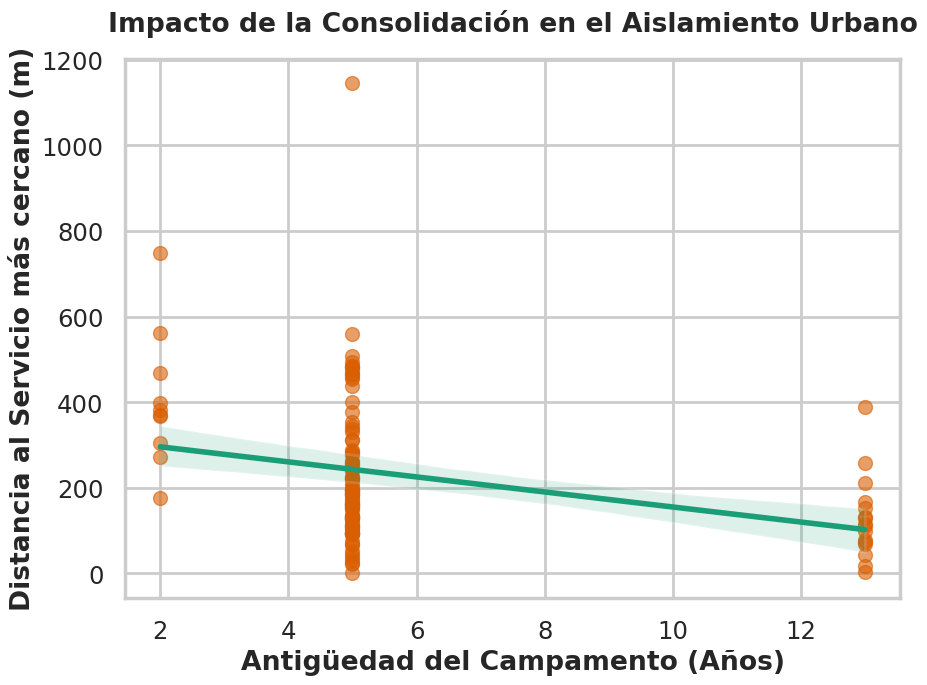

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("poster", font_scale=0.8)
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(10, 7))

sns.regplot(
    data=resultados_vina,
    x='antiguedad',
    y='Distancia_Minima_Servicios_m',
    scatter_kws={'alpha':0.6, 's':100, 'color':'#d95f02'}, # Puntos naranjas
    line_kws={'color':'#1b9e77', 'linewidth':4},          # Línea verde fuerte
    ax=ax
)

ax.set_title('Impacto de la Consolidación en el Aislamiento Urbano', fontweight='bold', pad=20)
ax.set_xlabel('Antigüedad del Campamento (Años)', fontweight='bold')
ax.set_ylabel('Distancia al Servicio más cercano (m)', fontweight='bold')

plt.savefig('grafico_antiguedad_aislamiento.png', dpi=300, bbox_inches='tight')
plt.show()

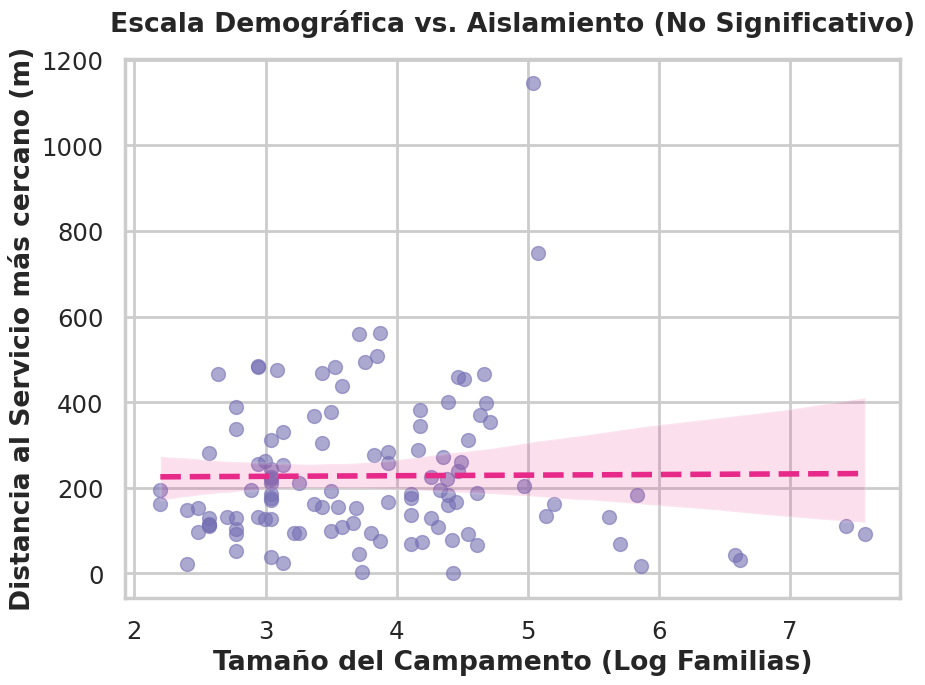

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.regplot(
    data=resultados_vina,
    x='log_familias',
    y='Distancia_Minima_Servicios_m',
    scatter_kws={'alpha':0.6, 's':100, 'color':'#7570b3'}, # Puntos morados
    line_kws={'color':'#e7298a', 'linewidth':4, 'linestyle':'--'}, # Línea segmentada
    ax=ax
)

ax.set_title('Escala Demográfica vs. Aislamiento (No Significativo)', fontweight='bold', pad=20)
ax.set_xlabel('Tamaño del Campamento (Log Familias)', fontweight='bold')
ax.set_ylabel('Distancia al Servicio más cercano (m)', fontweight='bold')

plt.savefig('grafico_familias_aislamiento.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_772/932031052.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


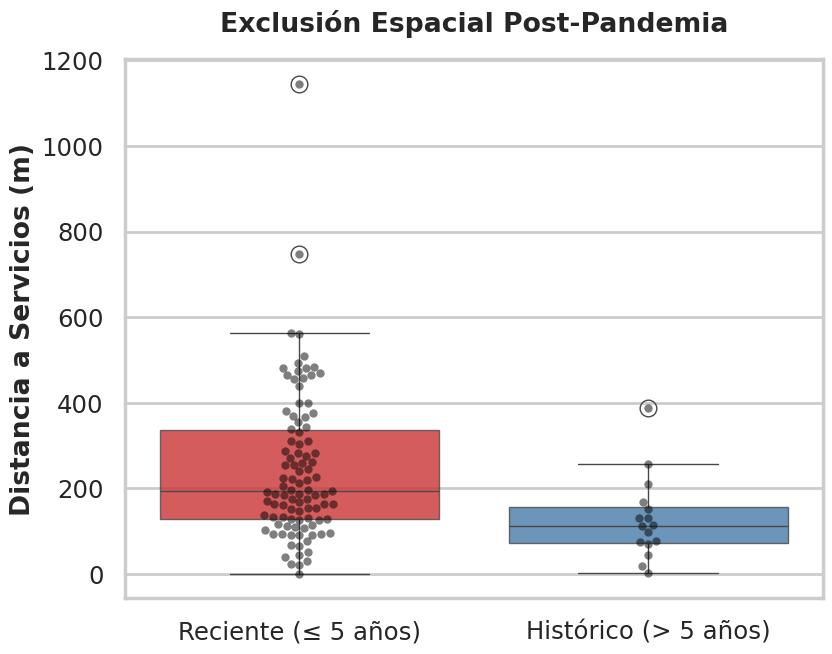

In [ ]:

resultados_vina['Tipo_Campamento'] = resultados_vina['antiguedad'].apply(
    lambda x: 'Reciente (≤ 5 años)' if x <= 5 else 'Histórico (> 5 años)'
)

fig, ax = plt.subplots(figsize=(9, 7))

sns.boxplot(
    data=resultados_vina,
    x='Tipo_Campamento',
    y='Distancia_Minima_Servicios_m',
    palette=['#e41a1c', '#377eb8'], # Rojo para nuevos, azul para antiguos
    ax=ax,
    boxprops=dict(alpha=0.8)
)

sns.swarmplot(
    data=resultados_vina,
    x='Tipo_Campamento',
    y='Distancia_Minima_Servicios_m',
    color='black',
    alpha=0.5,
    size=6
)

ax.set_title('Exclusión Espacial Post-Pandemia', fontweight='bold', pad=20)
ax.set_xlabel('')
ax.set_ylabel('Distancia a Servicios (m)', fontweight='bold')

plt.savefig('boxplot_nuevos_antiguos.png', dpi=300, bbox_inches='tight')
plt.show()

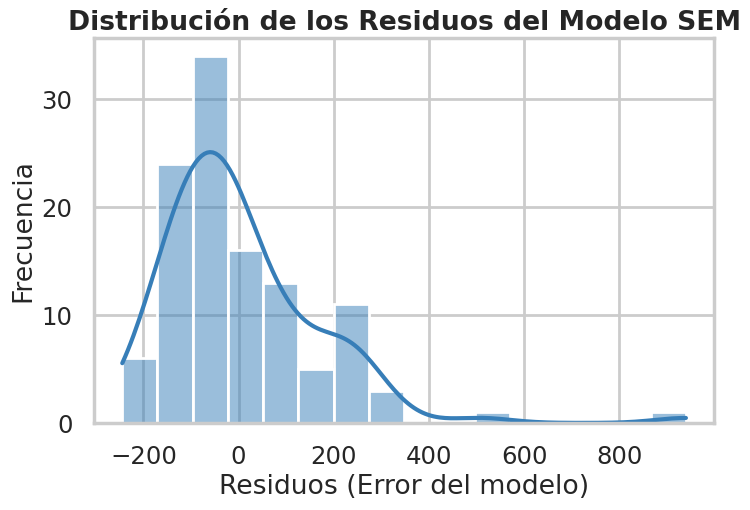


=== DIAGNÓSTICO DE RESIDUOS (VERIFICACIÓN DE SUPUESTOS) ===
Índice de Moran de los Residuos: 0.3050
Z-Score: 5.79
P-Valor: 0.0010

⚠️ ATENCIÓN: Aún existe dependencia espacial en los residuos. El modelo podría requerir más variables.


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from esda.moran import Moran
from splot.esda import plot_moran

# 1. Extraer los valores predichos y los residuos del modelo SEM
# (Asegúrate de haber ejecutado la celda anterior donde definiste 'modelo_final')
resultados_vina['valores_predichos'] = modelo_final.predy
resultados_vina['residuos'] = modelo_final.u

# 2. Diagnóstico 1: Normalidad de los Residuos
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(resultados_vina['residuos'], kde=True, color='#377eb8', ax=ax)
ax.set_title('Distribución de los Residuos del Modelo SEM', fontweight='bold')
ax.set_xlabel('Residuos (Error del modelo)')
ax.set_ylabel('Frecuencia')
plt.savefig('distribucion_residuos.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Diagnóstico 2: Autocorrelación Espacial de los Residuos (La prueba de fuego)
# Hacemos un test de Moran, pero esta vez SOBRE LOS RESIDUOS
moran_residuos = Moran(resultados_vina['residuos'], w)

print("\n=== DIAGNÓSTICO DE RESIDUOS (VERIFICACIÓN DE SUPUESTOS) ===")
print(f"Índice de Moran de los Residuos: {moran_residuos.I:.4f}")
print(f"Z-Score: {moran_residuos.z_sim:.2f}")
print(f"P-Valor: {moran_residuos.p_sim:.4f}")

if moran_residuos.p_sim > 0.05:
    print("\n✅ ÉXITO: El p-valor es mayor a 0.05. No hay autocorrelación espacial significativa en los residuos.")
    print("Conclusión: El modelo SEM logró controlar exitosamente la dependencia espacial.")
else:
    print("\n⚠️ ATENCIÓN: Aún existe dependencia espacial en los residuos. El modelo podría requerir más variables.")

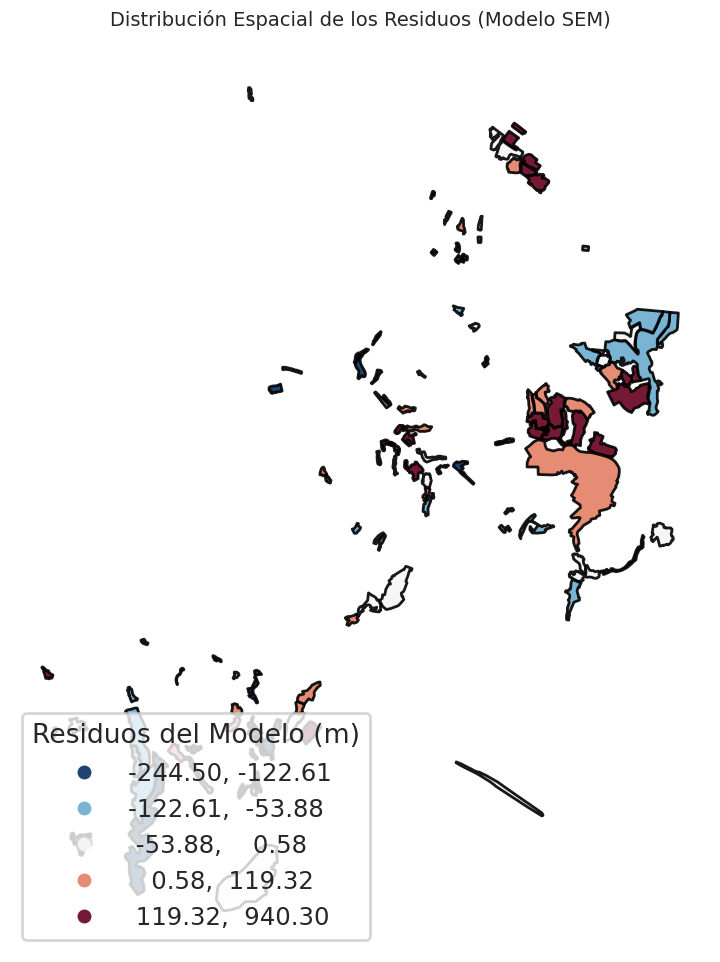

In [27]:
# Mapear los residuos para demostrar visualmente la aleatoriedad
fig, ax = plt.subplots(figsize=(10, 10))

# Capa base (fondo de Viña del Mar, opcional si lo tienes cargado)
# gdf_limite_vina_utm.plot(ax=ax, facecolor='#f7f7f7', edgecolor='#4d4d4d', zorder=1)

# Graficar los residuos usando un mapa de calor divergente (Rojo = Subestimado, Azul = Sobreestimado)
resultados_vina.plot(
    column='residuos',
    cmap='RdBu_r',       # Paleta divergente
    scheme='Quantiles',
    k=5,
    legend=True,
    ax=ax,
    legend_kwds={'title': "Residuos del Modelo (m)", 'loc': 'lower left'},
    markersize=60,
    edgecolor='black',
    alpha=0.9,
    zorder=2
)

ax.set_title("Distribución Espacial de los Residuos (Modelo SEM)", fontsize=14, pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('mapa_residuos_sem.png', dpi=300, bbox_inches='tight')
plt.show()